In [2]:
# %pip install -r requirements.txt

In [163]:
import pandas as pd

# for plotting missingness pattern
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# for regression imputation
import statsmodels.formula.api as smf

Clean: `patient_postoperative_complications`, `patient_information` and `patient_labs`.


# Postoperative Complications

In [7]:
# read in data
postop_raw = pd.read_csv("Data/patient_post_op_complications.csv")

# select relevant variables
postop_raw = postop_raw[["LOG_ID", "MRN", "SMRTDTA_ELEM_VALUE"]]

postop_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203945 entries, 0 to 203944
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   LOG_ID              203945 non-null  object
 1   MRN                 203945 non-null  object
 2   SMRTDTA_ELEM_VALUE  6741 non-null    object
dtypes: object(3)
memory usage: 4.7+ MB


In [8]:
postop_raw["LOG_ID"].nunique()

64214

In [9]:
# Remove rows with LOG_ID values corresponding to multiple MRNs

# group by log id and count MRN
log_mrn_count = postop_raw.groupby("LOG_ID")["MRN"].nunique()

# identify log ids with multiple MRN
ids_to_remove = log_mrn_count[log_mrn_count > 1].index 

# remove invalid log ids
# .copy().reset_index() to make sure it is a df and have continuous index
postop = postop_raw[~postop_raw["LOG_ID"].isin(ids_to_remove)].copy().reset_index(drop=True)

# check the the number of unique LOG_IDs after removing the invalid ids.
postop["LOG_ID"].nunique() 

64212

In [10]:
postop.head()

,LOG_ID,MRN,SMRTDTA_ELEM_VALUE
0,b00c588406aae5cc,1a42f0bed60c5598,NaN
1,a16571d21874c0a7,596a6dc60f54a0bb,NaN
2,a16571d21874c0a7,596a6dc60f54a0bb,NaN
3,1d9ff2d157fa4c86,60e6ea6cf06b58d7,NaN
4,2ae43a4a39735956,59c5483e0654e105,Other


# Patient Information

In [129]:
# read in data
info_raw = pd.read_csv("Data/patient_information.csv")

# select relevant variables
info_raw = info_raw[["LOG_ID", "MRN", "BIRTH_DATE", "HEIGHT", 
                        "WEIGHT", "SEX", "AN_START_DATETIME"]]

info_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65728 entries, 0 to 65727
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LOG_ID             65728 non-null  object 
 1   MRN                65728 non-null  object 
 2   BIRTH_DATE         65728 non-null  int64  
 3   HEIGHT             52695 non-null  object 
 4   WEIGHT             63319 non-null  float64
 5   SEX                65728 non-null  object 
 6   AN_START_DATETIME  58244 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 3.5+ MB


In [130]:
info_raw["LOG_ID"].nunique()

64354

In [131]:
# Remove rows with LOG_ID values corresponding to multiple MRNs

# group by log id and count MRN
log_mrn_count = info_raw.groupby("LOG_ID")["MRN"].nunique()

# identify log ids with multiple MRN
ids_to_remove = log_mrn_count[log_mrn_count > 1].index 

# remove invalid log ids
# .copy().reset_index() to make sure it is a df and have continuous index
information = info_raw[~info_raw["LOG_ID"].isin(ids_to_remove)].copy().reset_index(drop=True)

# check the the number of unique LOG_IDs after removing the invalid ids.
information["LOG_ID"].nunique() 

64350

## Clean variable type and name

### Anesthesia start date and time

Convert to Datetime

In [132]:
# Convert AN_START_TIME to Datetime

# check format
information.head()

,LOG_ID,MRN,BIRTH_DATE,HEIGHT,WEIGHT,SEX,AN_START_DATETIME
0,cd1636c6279d73a0,2e92522a5f2a2a22,47,NaN,2832.47,Female,12/20/18 12:27
1,fc53c06ee2cfe438,b7a91e623d957d8f,81,5' 6,2515.01,Male,9/27/19 9:52
2,2f0090c47da34608,b68d6c7198f30f73,49,NaN,1964.74,Female,4/8/19 14:41
3,6d3b621880c6ced4,46aa48e89b9c50e8,54,5' 3,2638.47,Female,12/3/18 8:09
4,82f89e10f2855420,c2756216cc89b795,44,NaN,1880.08,Female,4/19/19 8:14


In [133]:
information["AN_START_DATETIME"] = pd.to_datetime(information["AN_START_DATETIME"],
                                                  format = "%m/%d/%y %H:%M",
                                                  errors = "coerce")
information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65720 entries, 0 to 65719
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LOG_ID             65720 non-null  object        
 1   MRN                65720 non-null  object        
 2   BIRTH_DATE         65720 non-null  int64         
 3   HEIGHT             52687 non-null  object        
 4   WEIGHT             63311 non-null  float64       
 5   SEX                65720 non-null  object        
 6   AN_START_DATETIME  58238 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 3.5+ MB


In [134]:
information.head()

,LOG_ID,MRN,BIRTH_DATE,HEIGHT,WEIGHT,SEX,AN_START_DATETIME
0,cd1636c6279d73a0,2e92522a5f2a2a22,47,NaN,2832.47,Female,2018-12-20 12:27:00
1,fc53c06ee2cfe438,b7a91e623d957d8f,81,5' 6,2515.01,Male,2019-09-27 09:52:00
2,2f0090c47da34608,b68d6c7198f30f73,49,NaN,1964.74,Female,2019-04-08 14:41:00
3,6d3b621880c6ced4,46aa48e89b9c50e8,54,5' 3,2638.47,Female,2018-12-03 08:09:00
4,82f89e10f2855420,c2756216cc89b795,44,NaN,1880.08,Female,2019-04-19 08:14:00


### HEIGHT

Convert to meters

In [135]:
# split string by '
height_df = information["HEIGHT"].str.split("' ", expand=True)

# convert to numeric
feet = pd.to_numeric(height_df[0], errors = "coerce")
inches = pd.to_numeric(height_df[1], errors = "coerce")

# convert to meters
information["HEIGHT"] = 0.0254 * (feet * 12 + inches)
information.head()

,LOG_ID,MRN,BIRTH_DATE,HEIGHT,WEIGHT,SEX,AN_START_DATETIME
0,cd1636c6279d73a0,2e92522a5f2a2a22,47,NaN,2832.47,Female,2018-12-20 12:27:00
1,fc53c06ee2cfe438,b7a91e623d957d8f,81,1.6764,2515.01,Male,2019-09-27 09:52:00
2,2f0090c47da34608,b68d6c7198f30f73,49,NaN,1964.74,Female,2019-04-08 14:41:00
3,6d3b621880c6ced4,46aa48e89b9c50e8,54,1.6002,2638.47,Female,2018-12-03 08:09:00
4,82f89e10f2855420,c2756216cc89b795,44,NaN,1880.08,Female,2019-04-19 08:14:00


### WEIGHT
Convert to kg

In [136]:
# convert weight from ounces to kg
information["WEIGHT"] = 0.0283 * information["WEIGHT"]
information.head()

,LOG_ID,MRN,BIRTH_DATE,HEIGHT,WEIGHT,SEX,AN_START_DATETIME
0,cd1636c6279d73a0,2e92522a5f2a2a22,47,NaN,80.158901,Female,2018-12-20 12:27:00
1,fc53c06ee2cfe438,b7a91e623d957d8f,81,1.6764,71.174783,Male,2019-09-27 09:52:00
2,2f0090c47da34608,b68d6c7198f30f73,49,NaN,55.602142,Female,2019-04-08 14:41:00
3,6d3b621880c6ced4,46aa48e89b9c50e8,54,1.6002,74.668701,Female,2018-12-03 08:09:00
4,82f89e10f2855420,c2756216cc89b795,44,NaN,53.206264,Female,2019-04-19 08:14:00


### BIRTH_DATE

Rename to AGE

In [137]:
# rename BIRTH_DATE to AGE
information.rename(columns = {"BIRTH_DATE": "AGE"}, inplace = True)
information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65720 entries, 0 to 65719
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LOG_ID             65720 non-null  object        
 1   MRN                65720 non-null  object        
 2   AGE                65720 non-null  int64         
 3   HEIGHT             52687 non-null  float64       
 4   WEIGHT             63311 non-null  float64       
 5   SEX                65720 non-null  object        
 6   AN_START_DATETIME  58238 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 3.5+ MB


## Missing values

- `SEX` (not as NaN but as "Unknown")
- `HEIGHT` and `WEIGHT`
- `AN_START_TIME`

### Check missing patterns

<Figure size 1200x800 with 0 Axes>

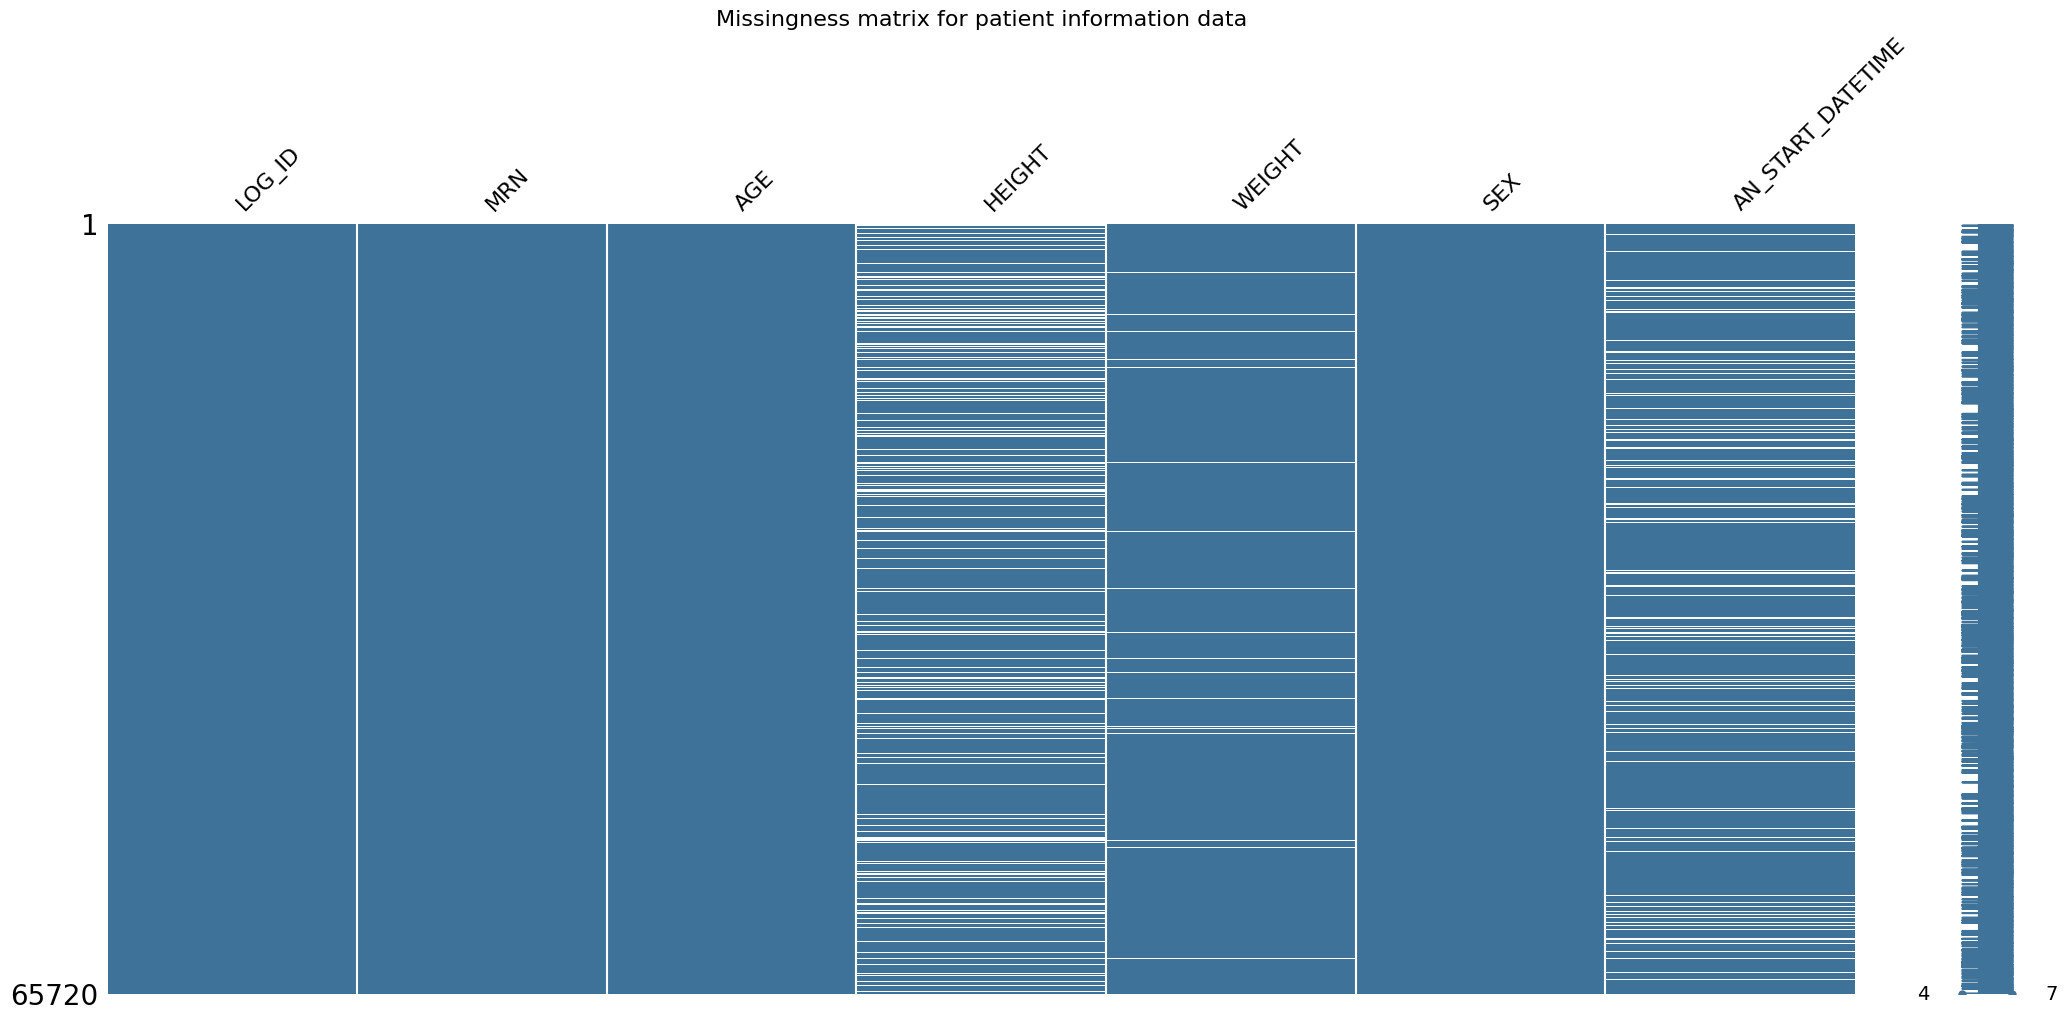

In [138]:
# visualize missing pattern
plt.figure(figsize=(12, 8))

# filter=top/bottom can help if you have 50+ columns
msno.matrix(information, sparkline = True, color = (0.25, 0.45, 0.6)) 
plt.title("Missingness matrix for patient information data", fontsize=16)
plt.show()

- Does not appear MNAR (now "chunks" of missing values), proposed imputation methods are reasonable

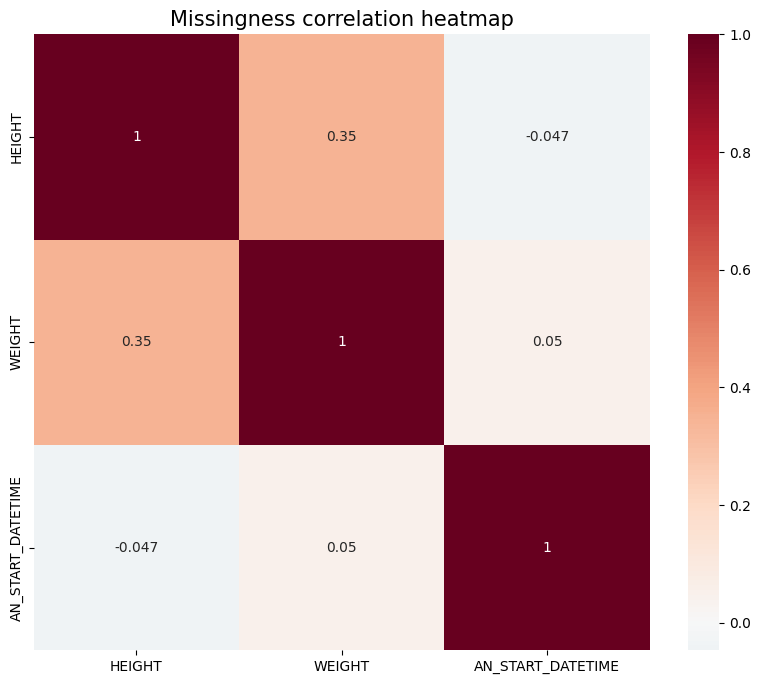

In [139]:
# Correlation heatmap
# only cols that has missings
plt.figure(figsize=(10, 8))

# identify columns with missing values
cols_with_missing = information.columns[information.isnull().any()]

# create correlation matrix for missing values
missing_cor = information[cols_with_missing].isnull().corr()

# heatmap
sns.heatmap(missing_cor, 
            annot=True,          # Shows the correlation numbers
            cmap='RdBu_r',       # Red/Blue color scheme (standard for correlations)
            center=0,            # Ensures 0 is the neutral color
            square=True)         # Forces the cells to be square

plt.title("Missingness correlation heatmap", fontsize=15)
plt.show()

- Missing values in HEIGHT and WEIGHT appear to be weakly positively correlated

### SEX

In [140]:
# check unique values of SEX variable
information["SEX"].unique()

array(['Female', 'Male', 'Unknown'], dtype=object)

In [141]:
information[information["SEX"] == "Unknown"]["LOG_ID"].nunique()

1

In [142]:
# drop "Unknown" SEX
information = information[information["SEX"] != "Unknown"].copy().reset_index(drop=True) # ensure the result is a DF
information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65719 entries, 0 to 65718
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LOG_ID             65719 non-null  object        
 1   MRN                65719 non-null  object        
 2   AGE                65719 non-null  int64         
 3   HEIGHT             52687 non-null  float64       
 4   WEIGHT             63311 non-null  float64       
 5   SEX                65719 non-null  object        
 6   AN_START_DATETIME  58238 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 3.5+ MB


In [143]:
information["SEX"].unique()

array(['Female', 'Male'], dtype=object)

### AN_START_DATETIME

In [144]:
# drop missing anesthesia start time
information = information.dropna(subset = ["AN_START_DATETIME"]).reset_index(drop=True)
information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58238 entries, 0 to 58237
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LOG_ID             58238 non-null  object        
 1   MRN                58238 non-null  object        
 2   AGE                58238 non-null  int64         
 3   HEIGHT             46301 non-null  float64       
 4   WEIGHT             56300 non-null  float64       
 5   SEX                58238 non-null  object        
 6   AN_START_DATETIME  58238 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 3.1+ MB


### HEIGHT and WEIGHT

#### Forward fill

Fill in missing values using the last available value, partitioned by MRN, orderd by anesthesia start date.

In [167]:
# sort data by MRN and AN_START_DATETIME
info_sorted = information.sort_values(by = ["MRN", "AN_START_DATETIME"])

# group by MRN and apply ffill
info_sorted['HEIGHT'] = info_sorted.groupby("MRN")["HEIGHT"].ffill()
info_sorted['WEIGHT'] = info_sorted.groupby("MRN")["WEIGHT"].ffill()
info_sorted = info_sorted.copy().reset_index(drop=True)

In [168]:
info_sorted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58238 entries, 0 to 58237
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LOG_ID             58238 non-null  object        
 1   MRN                58238 non-null  object        
 2   AGE                58238 non-null  int64         
 3   HEIGHT             48728 non-null  float64       
 4   WEIGHT             56895 non-null  float64       
 5   SEX                58238 non-null  object        
 6   AN_START_DATETIME  58238 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 3.1+ MB


In [169]:
info_sorted.head()

,LOG_ID,MRN,AGE,HEIGHT,WEIGHT,SEX,AN_START_DATETIME
0,bd16a67880da1e77,0000c7ccaa009343,39,1.6764,74.468903,Female,2019-02-24 08:59:00
1,47fbfb9938d6067b,0000c7ccaa009343,39,1.6764,73.470762,Female,2019-03-31 16:02:00
2,611e9c50425dbf55,0000e45237d1fc96,52,1.8288,99.824288,Male,2021-02-13 07:11:00
3,be9a505e236e5b67,000181ce0ebf1e12,31,NaN,NaN,Male,2023-07-06 10:13:00
4,189a1d9df810fe26,00018b4d9acb258b,80,1.8796,98.726248,Male,2020-08-03 07:10:00


#### Regression imputation

Impute HEIGHT:
1. Train on rows where HEIGHT is present.
2. Predict where HEIGHT is missing (using SEX and WEIGHT).

Impute WEIGHT:
1. Train on rows where WEIGHT is present.
2. Predict where WEIGHT is missing (using SEX and the newly filled HEIGHT).
   
Drop rows missing both height and weight after imputation

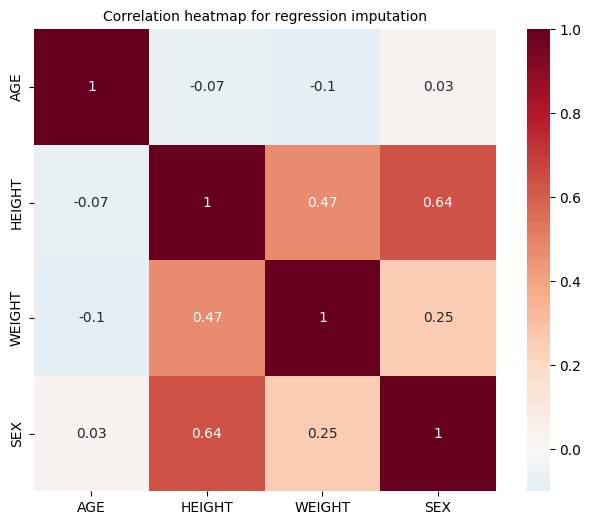

In [164]:
# potential predictors
predictors = ["AGE", "HEIGHT", "WEIGHT", "SEX"]
predictors_df = information[cols].reset_index(drop=True)
predictors_df["SEX"] = predictors_df["SEX"].map({"Female": 0, "Male": 1}) # convert sex to 0/1 for plotting

# check correlation
plt.figure(figsize=(8, 6))

# create correlation matrix
predictors_corr = predictors_df.corr()

# heatmap
sns.heatmap(predictors_corr, 
            annot=True,          
            cmap='RdBu_r',   
            center=0,
            square=True)

plt.title("Correlation heatmap for regression imputation", fontsize=10)
plt.show()

In [170]:
info_clean = info_sorted.copy()

In [171]:
# impute height

# partition data into train (complete) and test (missing) sets
# ensure WEIGHT is not missing because we need it as a predictor
h_train = info_clean[info_clean["HEIGHT"].notna() & info_clean["WEIGHT"].notna()]
h_miss = info_clean[info_clean["HEIGHT"].isna() & info_clean["WEIGHT"].notna()]

# model for height
# include random effect for MRN
model_h = smf.mixedlm("HEIGHT ~ SEX + WEIGHT", h_train, groups = h_train["MRN"]).fit()

# predict and impute
info_clean.loc[h_miss.index, "HEIGHT"] = model_h.predict(h_miss)
info_clean.info()

/Users/ly_nnnn/miniconda3/envs/CHL8010/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58238 entries, 0 to 58237
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LOG_ID             58238 non-null  object        
 1   MRN                58238 non-null  object        
 2   AGE                58238 non-null  int64         
 3   HEIGHT             57026 non-null  float64       
 4   WEIGHT             56895 non-null  float64       
 5   SEX                58238 non-null  object        
 6   AN_START_DATETIME  58238 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 3.1+ MB


In [173]:
# impute weight
w_train = info_clean[info_clean['WEIGHT'].notna() & info_clean['HEIGHT'].notna()]
w_miss  = info_clean[info_clean['WEIGHT'].isna() & info_clean['HEIGHT'].notna()]

# model for weight
# include random effect for MRN
model_w = smf.mixedlm("WEIGHT ~ SEX + HEIGHT", w_train, groups = w_train["MRN"]).fit()

# predict and impute
info_clean.loc[w_miss.index, "WEIGHT"] = model_w.predict(w_miss)
info_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58238 entries, 0 to 58237
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LOG_ID             58238 non-null  object        
 1   MRN                58238 non-null  object        
 2   AGE                58238 non-null  int64         
 3   HEIGHT             57026 non-null  float64       
 4   WEIGHT             57026 non-null  float64       
 5   SEX                58238 non-null  object        
 6   AN_START_DATETIME  58238 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 3.1+ MB


In [174]:
# Drop observations with both missing height and weight
info_clean = info_clean.dropna(subset = ["HEIGHT", "WEIGHT"], how = "all").reset_index(drop=True)
info_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57026 entries, 0 to 57025
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LOG_ID             57026 non-null  object        
 1   MRN                57026 non-null  object        
 2   AGE                57026 non-null  int64         
 3   HEIGHT             57026 non-null  float64       
 4   WEIGHT             57026 non-null  float64       
 5   SEX                57026 non-null  object        
 6   AN_START_DATETIME  57026 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 3.0+ MB


#### Check imputation validity
* To be done in validation.py?

# Patient Labs

In [176]:
# read in data
labs_raw = pd.read_csv("Data/patient_labs.csv")

# select relevant variables
labs_raw = labs_raw[["LOG_ID", "MRN", "Lab Code", "Lab Name", "Observation Value", 
                 "Measurement Units", "Collection Datetime"]]

labs_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29079344 entries, 0 to 29079343
Data columns (total 7 columns):
 #   Column               Dtype  
---  ------               -----  
 0   LOG_ID               object 
 1   MRN                  object 
 2   Lab Code             object 
 3   Lab Name             object 
 4   Observation Value    float64
 5   Measurement Units    object 
 6   Collection Datetime  object 
dtypes: float64(1), object(6)
memory usage: 1.5+ GB
